In [1]:
import netCDF4
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from tqdm import tqdm
from shapely.geometry import Point
from scipy.stats import skew, kurtosis, entropy
from scipy.fft import fft
import os
import pyarrow as pa
import pyarrow.parquet as pq
from sklearn.model_selection import train_test_split
from joblib import Parallel, delayed

from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from collections import defaultdict
import cv2
from skimage.feature import graycomatrix, graycoprops
from skimage.measure import regionprops
import warnings

from sklearn.cluster import DBSCAN

import numpy as np
import gc
from typing import List, Dict, Iterator, Any

warnings.filterwarnings('ignore')

In [2]:
ROOT_DIR = 'E:/data/RONGOWAI_L1_SDR_V1.0/' #"./sample_data/" # Change this to your root directory
os.environ['ROOT_DIR'] = ROOT_DIR
OUTPUT_DIR = './processed_data/'  # Directory to save processed data
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR) 
os.environ['OUTPUT_DIR'] = OUTPUT_DIR

In [3]:
class NetCDFPreprocessor:
    def __init__(self, root_dir, preprocessing_method=str, return_sp_centers=bool):
        self.root_dir = root_dir
        self.netcdf_file_list = os.listdir(root_dir)
        self.preprocessing_method = preprocessing_method
        self.return_sp_centers = return_sp_centers
        if self.preprocessing_method not in ['filtered', 'with_lat_lons', 'unfiltered']:
            raise ValueError("Invalid preprocessing method. Choose from 'filtered', 'with_lat_lons', or 'unfiltered'.")

    @staticmethod
    def check_integrity(f):
        """Check integrity of the netCDF file"""
        if not isinstance(f, netCDF4.Dataset):
            raise ValueError("Input must be a netCDF4.Dataset object")
        if 'raw_counts' not in f.variables:
            raise KeyError("The netCDF file does not contain 'raw_counts' variable")
        if 'sp_alt' not in f.variables or 'sp_inc_angle' not in f.variables:
            raise KeyError("The netCDF file does not contain 'sp_alt' or 'sp_inc_angle' variables")
        if 'sp_rx_gain_copol' not in f.variables or 'sp_rx_gain_xpol' not in f.variables or 'ddm_snr' not in f.variables:
            raise KeyError("The netCDF file does not contain 'sp_rx_gain_copol', 'sp_rx_gain_xpol' or 'ddm_snr' variables")
        if 'sp_lat' not in f.variables or 'sp_lon' not in f.variables:
            raise KeyError("The netCDF file does not contain 'sp_lat' or 'sp_lon' variables")
        if 'sp_surface_type' not in f.variables:
            raise KeyError("The netCDF file does not contain 'sp_surface_type' variable")
        if 'ac_alt' not in f.variables:
            raise KeyError("The netCDF file does not contain 'ac_alt' variable")
        if f.variables['raw_counts'].ndim != 4:
            raise ValueError("The 'raw_counts' variable must have 4 dimensions")

    def preprocess_snr_filtered(self, f):
        """ Preprocess the netCDF file and return fit data, labels and specular point centers with filtering on signal-to-noise ratio """
        # Check integrity of the netCDF file
        self.check_integrity(f)

        raw_counts = f.variables['raw_counts'][:]
        ac_alt = f.variables['ac_alt'][:]
        sp_alt = f.variables['sp_alt'][:]
        copol = f.variables['sp_rx_gain_copol'][:]
        xpol = f.variables['sp_rx_gain_xpol'][:]
        snr = f.variables['ddm_snr'][:]
        sp_inc_angle = f.variables['sp_inc_angle'][:]
        sp_center_bin_delay_row = f.variables['brcs_ddm_peak_bin_delay_row'][:]
        sp_center_bin_delay_col = f.variables['brcs_ddm_peak_bin_dopp_col'][:]

        distance_2d = (ac_alt[:, np.newaxis] - sp_alt) / np.cos(np.deg2rad(sp_inc_angle)) # Distance between the aircraft and the specular point

        # Filtering mask
        keep_mask = (
            (copol >= 5) & # # SP copolarized gain
            (xpol >= 5) & # SP cross-polarized gain
            (snr > 0) & # Positive signal-to-Noise Ratio
            (distance_2d >= 2000) & #SP distance min
            (distance_2d <= 10000) & #SP distance max
            ~np.isnan(copol) & 
            ~np.isnan(xpol) & 
            ~np.isnan(snr) & 
            ~np.isnan(distance_2d)
        )

        aux_row_counts = np.full(raw_counts.shape, np.nan, dtype=np.float32)
        aux_array_sp_row = np.full(sp_center_bin_delay_row.shape, np.nan, dtype=np.float32)
        aux_array_sp_col = np.full(sp_center_bin_delay_col.shape, np.nan, dtype=np.float32)
        
        i_indices, j_indices = np.where(keep_mask)
        aux_row_counts[i_indices, j_indices] = raw_counts[i_indices, j_indices]
        aux_array_sp_row[i_indices, j_indices] = sp_center_bin_delay_row[i_indices, j_indices]
        aux_array_sp_col[i_indices, j_indices] = sp_center_bin_delay_col[i_indices, j_indices]

        assert aux_row_counts.shape[0] == aux_array_sp_row.shape[0] , "First dimension mismatch among aux_row_counts and aux_array_sp_row arrays"
        assert aux_row_counts.shape[0] == aux_array_sp_col.shape[0] , "First dimension mismatch among aux_row_counts and aux_array_sp_col arrays"

        n_time, n_samples = raw_counts.shape[:2]
        aux_raw_counts_reshaped = aux_row_counts.reshape(n_time * n_samples, *raw_counts.shape[2:])
        aux_array_sp_row_reshaped = aux_array_sp_row.reshape(n_time * n_samples, *aux_array_sp_row.shape[2:])
        aux_array_sp_col_reshaped = aux_array_sp_col.reshape(n_time * n_samples, *aux_array_sp_col.shape[2:])

        assert aux_raw_counts_reshaped.shape[0] == aux_array_sp_row_reshaped.shape[0], "First dimension mismatch among aux_raw_counts_reshaped and aux_array_sp_row_reshaped arrays after reshaping"
        assert aux_raw_counts_reshaped.shape[0] == aux_array_sp_col_reshaped.shape[0], "First dimension mismatch among aux_raw_counts_reshaped and aux_array_sp_col_reshaped arrays after reshaping"
        #freeing memory
        del aux_row_counts
        del aux_array_sp_row
        del aux_array_sp_col

        # Filter out NaN and zero-sum rows
        valid_mask = ~np.any(np.isnan(aux_raw_counts_reshaped), axis=(1, 2)) & (np.sum(aux_raw_counts_reshaped, axis=(1, 2)) > 0)

        sp_center_bin_delay_row_filtered = aux_array_sp_row_reshaped[valid_mask]
        sp_center_bin_delay_col_filtered = aux_array_sp_col_reshaped[valid_mask]
        sp_centers_filtered = list(zip(sp_center_bin_delay_row_filtered.flatten(), sp_center_bin_delay_col_filtered.flatten()))

        fit_data = aux_raw_counts_reshaped[valid_mask].reshape(valid_mask.sum(), -1)

        assert len(sp_centers_filtered) == fit_data.shape[0], "First dimension sp_centers_filtered and fit_data mismatch after reshaping"


        surface_types = np.nan_to_num(f.variables["sp_surface_type"][:], nan=0).ravel()
        label_data = np.isin(surface_types, np.arange(1, 8)).astype(np.int32)
        label_data = label_data[valid_mask]
        
        # Ensure that fit_data and label_data have the same length
        assert fit_data.shape[0] == len(label_data), \
            f"Shape mismatch: fit_data {fit_data.shape[0]}, label_data {len(label_data)}"

        assert len(sp_centers_filtered) == fit_data.shape[0], "First dimension sp_centers_filtered and fit_data mismatch after reshaping"

        if self.return_sp_centers:
            return fit_data, label_data, sp_centers_filtered
        else:
            return fit_data, label_data


    def preprocess_snr_unfiltered(self, f):
        """ Preprocess the netCDF file and return fit data, labels and specular point centers without filtering on signal-to-noise ratio """
        # Check integrity of the netCDF file
        self.check_integrity(f)

        raw_counts = f.variables['raw_counts'][:]
        ac_alt = f.variables['ac_alt'][:]
        sp_alt = f.variables['sp_alt'][:]
        sp_inc_angle = f.variables['sp_inc_angle'][:]
        copol = f.variables['sp_rx_gain_copol'][:]
        xpol = f.variables['sp_rx_gain_xpol'][:]
        #snr = f.variables['ddm_snr'][:]
        sp_center_bin_delay_row = f.variables['brcs_ddm_peak_bin_delay_row'][:]
        sp_center_bin_delay_col = f.variables['brcs_ddm_peak_bin_dopp_col'][:]

        #Distance between the aircraft and the specular point
        distance_2d = (ac_alt[:, np.newaxis] - sp_alt) / np.cos(np.deg2rad(sp_inc_angle))
        # Filtering mask without SNR
        keep_mask = (
            (copol >= 5) & 
            (xpol >= 5) & 
        #   (snr > 0)  &
            (distance_2d >= 2000) & 
            (distance_2d <= 10000) &
            ~np.isnan(copol) & 
            ~np.isnan(xpol) & 
            #~np.isnan(snr) & 
            ~np.isnan(distance_2d)
        )
    
        aux_row_counts = np.full(raw_counts.shape, np.nan, dtype=np.float32)
        aux_array_sp_row = np.full(sp_center_bin_delay_row.shape, np.nan, dtype=np.float32)
        aux_array_sp_col = np.full(sp_center_bin_delay_col.shape, np.nan, dtype=np.float32)

        i_indices, j_indices = np.where(keep_mask)

        aux_row_counts[i_indices, j_indices] = raw_counts[i_indices, j_indices]
        aux_array_sp_row[i_indices, j_indices] = sp_center_bin_delay_row[i_indices, j_indices]
        aux_array_sp_col[i_indices, j_indices] = sp_center_bin_delay_col[i_indices, j_indices]

        assert aux_row_counts.shape[0] == aux_array_sp_row.shape[0] , "First dimension mismatch among aux_row_counts and aux_array_sp_row arrays"
        assert aux_row_counts.shape[0] == aux_array_sp_col.shape[0] , "First dimension mismatch among aux_row_counts and aux_array_sp_col arrays"

        n_time, n_samples = raw_counts.shape[:2]
        aux_raw_counts_reshaped = aux_row_counts.reshape(n_time * n_samples, *raw_counts.shape[2:])
        aux_array_sp_row_reshaped = aux_array_sp_row.reshape(n_time * n_samples, *aux_array_sp_row.shape[2:])
        aux_array_sp_col_reshaped = aux_array_sp_col.reshape(n_time * n_samples, *aux_array_sp_col.shape[2:])


        assert aux_raw_counts_reshaped.shape[0] == aux_array_sp_row_reshaped.shape[0], "First dimension mismatch among aux_raw_counts_reshaped and aux_array_sp_row_reshaped arrays after reshaping"
        assert aux_raw_counts_reshaped.shape[0] == aux_array_sp_col_reshaped.shape[0], "First dimension mismatch among aux_raw_counts_reshaped and aux_array_sp_col_reshaped arrays after reshaping"

        del aux_row_counts
        del aux_array_sp_row
        del aux_array_sp_col

        valid_mask = ~np.any(np.isnan(aux_raw_counts_reshaped), axis=(1, 2)) & (np.sum(aux_raw_counts_reshaped, axis=(1, 2)) > 0)

        sp_center_bin_delay_row_filtered = aux_array_sp_row_reshaped[valid_mask]
        sp_center_bin_delay_col_filtered = aux_array_sp_col_reshaped[valid_mask]
        sp_centers_filtered = list(zip(sp_center_bin_delay_row_filtered.flatten(), sp_center_bin_delay_col_filtered.flatten()))

        fit_data = aux_raw_counts_reshaped[valid_mask].reshape(valid_mask.sum(), -1)

        assert len(sp_centers_filtered) == fit_data.shape[0], "First dimension sp_centers_filtered and fit_data mismatch after reshaping"
    
        surface_types = np.nan_to_num(f.variables["sp_surface_type"][:], nan=0).ravel()
        label_data = np.isin(surface_types, np.arange(1, 8)).astype(np.int32)
        label_data = label_data[valid_mask]
        # Ensure that fit_data and label_data have the same length
        assert fit_data.shape[0] == len(label_data), \
            f"Shape mismatch: fit_data {fit_data.shape[0]}, label_data {len(label_data)}"

        assert len(sp_centers_filtered) == fit_data.shape[0], "First dimension sp_centers_filtered and fit_data mismatch after reshaping"

        if self.return_sp_centers:
            return fit_data, label_data, sp_centers_filtered
        else:
            return fit_data, label_data


    def process_all_files_random_picked(self, chunk_size = int, sample_fraction = float, n_files_to_pick= int, remove_chunks= bool):
        """ Process all netCDF files in the directory, randomly picking a specified number of files,
        and save the processed data and labels in chunks."""

        full_data = []
        full_labels = []
        full_sp_centers = []
        counter = 0

        # Take a random number of netCDF files
        if int(len(self.netcdf_file_list)) > n_files_to_pick: # type: ignore
            np.random.seed(42)
            random_netcdf_selected_files = np.random.choice(self.netcdf_file_list, n_files_to_pick, replace=False) # type: ignore
            print(f'Selezionati {n_files_to_pick} file netCDF casuali dalla lista')
        else:
            random_netcdf_selected_files = self.netcdf_file_list

        for file_name in tqdm(random_netcdf_selected_files, desc="Processing files"):
            if not file_name.endswith('.nc'):
                continue
            try:
                f = netCDF4.Dataset(f'{self.root_dir}{file_name}')
                
                if self.preprocessing_method == 'unfiltered' and self.return_sp_centers:
                    data, labels, sp_centers = self.preprocess_snr_unfiltered(f)
                elif self.preprocessing_method == 'unfiltered' and not self.return_sp_centers:
                    data, labels = self.preprocess_snr_unfiltered(f)
                    sp_centers = [(-1, -1)] * len(labels)  # Placeholder if sp_centers are not returned

                elif self.preprocessing_method == 'filtered' and self.return_sp_centers:
                    data, labels, sp_centers = self.preprocess_snr_filtered(f)
                elif self.preprocessing_method == 'filtered' and not self.return_sp_centers:
                    data, labels = self.preprocess_snr_filtered(f)
                    sp_centers = [(-1, -1)] * len(labels)  # Placeholder if sp_centers are not returned

                #elif self.preprocessing_method == 'with_lat_lons':
                #    data, labels, latitudes, longitudes = self.preprocess_w_lat_lons(f)
                else:
                    # Default to filtered preprocessing
                    if self.return_sp_centers:
                        data, labels, sp_centers = self.preprocess_snr_filtered(f)
                    else:
                        data, labels = self.preprocess_snr_filtered(f)
                        sp_centers = [(-1, -1)] * len(labels)  # Placeholder if sp_centers are not returned

                    data, labels, sp_centers = self.preprocess_snr_unfiltered(f)
                   
                assert (len(data) == len(labels)), f"Data and labels length mismatch in file {file_name}: {len(data)} != {len(labels)}"
                full_data.append(data)
                full_labels.append(labels)
                full_sp_centers.append(sp_centers)
            except Exception as e:
                print(f"Error processing file {file_name}: {e}")
                continue
            counter += 1
            if counter == n_files_to_pick:
                break
        print(f"Processed {counter} files out of {len(random_netcdf_selected_files)} selected files.")

        # Filtering on data shape
        valid_indices = [i for i, arr in enumerate(full_data) if arr.ndim == 2 if arr.shape[1] == 200]
        full_data_clean = [full_data[i] for i in valid_indices]
        full_labels_clean = [full_labels[i] for i in valid_indices]
        full_sp_centers = [full_sp_centers[i] for i in valid_indices]

        assert len(full_sp_centers) == len(full_data_clean), "First dimension sp_centers and fit_data mismatch after reshaping"

        # Chunking
        os.makedirs('temp_data/binary_classification', exist_ok=True)

        full_data_sampled = []
        full_labels_sampled = []
        full_sp_centers_sampled = []

        num_chunks = int(np.ceil(len(full_data_clean) / chunk_size))  # type: ignore
        print(f"Total number of chunks: {num_chunks}")
        for idx in range(num_chunks):
            start = idx * chunk_size # type: ignore
            end = min((idx + 1) * chunk_size, len(full_data_clean)) # type: ignore
            
            chunk_data = np.vstack(full_data_clean[start:end])
            chunk_labels = np.hstack(full_labels_clean[start:end])
            chunk_sp_centers = np.vstack(full_sp_centers[start:end])

            if chunk_data.size == 0 or chunk_labels.size == 0:
                print(f"Skipping empty chunk {idx + 1}/{num_chunks}")
                continue
            print(f"Chunk {idx + 1}/{num_chunks} processed with shape {chunk_data.shape} and labels shape {chunk_labels.shape} and sp_centers shape {chunk_sp_centers.shape}")

            # Save each chunk to parquet files
            if chunk_data.shape[0] == 0 or chunk_labels.shape[0] == 0 or chunk_sp_centers.shape[0] == 0:
                print(f"Skipping empty chunk {idx + 1}/{num_chunks}")
                continue

            fit_data_df = pd.DataFrame(chunk_data)
            labels_df = pd.DataFrame(chunk_labels, columns=['label'])
            sp_centers_df = pd.DataFrame(chunk_sp_centers, columns=['delay', 'dopp'])

            table_fit = pa.Table.from_pandas(fit_data_df, preserve_index=False)
            table_labels = pa.Table.from_pandas(labels_df, preserve_index=False)
            table_sp_centers = pa.Table.from_pandas(sp_centers_df, preserve_index=False)

            pq.write_table(
                table_fit,
                f'temp_data/binary_classification/fit_data_chunk_{idx}.parquet',
                compression='zstd',
                use_dictionary=True,
            )
            pq.write_table(
                table_labels,
                f'temp_data/binary_classification/labels_chunk_{idx}.parquet',
                compression='zstd',
                use_dictionary=True,
            )
            pq.write_table(
                table_sp_centers,
                f'temp_data/binary_classification/sp_centers_chunk_{idx}.parquet',
                compression='zstd',
                use_dictionary=True,
            )

            _, X_sampled, _, y_sampled, _, sp_centers_sampled = train_test_split(
                chunk_data,
                chunk_labels,
                chunk_sp_centers,
                test_size=sample_fraction, # e.g., 0.1 for 10% sampling
                stratify=chunk_labels,
                random_state=42
            )
            print(f"Chunk {idx + 1}/{num_chunks} sampled to shape {X_sampled.shape} and labels shape {y_sampled.shape} and sp_centers shape {sp_centers_sampled.shape}")
            
            full_data_sampled.append(X_sampled)
            full_labels_sampled.append(y_sampled)
            full_sp_centers_sampled.append(sp_centers_sampled)

        del full_data, full_labels

        full_data_sampled_stratified = np.vstack(full_data_sampled)
        full_labels_sampled_stratified = np.hstack(full_labels_sampled)
        full_sp_centers_sampled_stratified = np.vstack(full_sp_centers_sampled)

        del full_data_sampled, full_labels_sampled, full_sp_centers_sampled
        print(f"Shape of sampled data after chunking and sampling: {np.array(full_data_sampled_stratified).shape}")
        print(f"Shape of sampled labels after chunking and sampling: {np.array(full_labels_sampled_stratified).shape}")
        print(f"Unique classes in sampled labels: {np.unique(full_labels_sampled_stratified, return_counts=True)}")
        print(f"Shape of sampled sp_centers after chunking and sampling: {np.array(full_sp_centers_sampled_stratified).shape}")

        # Save the final sampled data and labels in parquet format
        if not os.path.exists('temp_data/binary_classification'):
            print("Creating directory temp_data/binary_classification")
            os.makedirs('temp_data/binary_classification', exist_ok=True)

        # Save fit_data 
        fit_data_df = pd.DataFrame(full_data_sampled_stratified)
        table_fit = pa.Table.from_pandas(fit_data_df, preserve_index=False)
        pq.write_table(
            table_fit,
            'temp_data/binary_classification/fit_data_binary_test.parquet',
            compression='zstd',
            use_dictionary=True,
        )
        # Save labels
        labels_df = pd.DataFrame(full_labels_sampled_stratified, columns=['label'])
        table_labels = pa.Table.from_pandas(labels_df, preserve_index=False)
        pq.write_table(
            table_labels,
            'temp_data/binary_classification/labels_binary_test.parquet',
            compression='zstd',
            use_dictionary=True,
        )
        # Save sp_centers
        sp_centers_df = pd.DataFrame(full_sp_centers_sampled_stratified, columns=['delay', 'dopp'])
        table_sp_centers = pa.Table.from_pandas(sp_centers_df, preserve_index=False)
        pq.write_table(
            table_sp_centers,
            'temp_data/binary_classification/sp_centers_binary_test.parquet',
            compression='zstd',
            use_dictionary=True,
        )
        # Clean up
        del fit_data_df, labels_df, table_fit, table_labels, sp_centers_df, table_sp_centers

        print("Data and labels saved in temp_data/binary_classification directory.")
        # Remove all chunk parquet files if flag is set (to save space)
        if remove_chunks:
            try:
                chunk_dir = 'temp_data/binary_classification'
                for fname in os.listdir(chunk_dir):
                    if fname.startswith('fit_data_chunk_') or fname.startswith('labels_chunk_') or fname.startswith('sp_centers_chunk_'):
                        os.remove(os.path.join(chunk_dir, fname))
                print("All chunk files removed.")
            except Exception as e:
                print(f"Error removing chunk files: {e}")
        if self.return_sp_centers:
            return full_data_sampled_stratified, full_labels_sampled_stratified, full_sp_centers_sampled_stratified
        else:
            return full_data_sampled_stratified, full_labels_sampled_stratified



In [4]:
class PeakRegionDetector:
    """
    Classe per trovare regioni di picco in immagini 5x40.
    """
    def __init__(self, N=10, method='statistical'):
        """
        Inizializza il detector.
        
        Parameters:
        -----------
        N : int, default=10
            Numero massimo di pixel nella regione
        method : str, default='statistical'
            Metodo da usare: 'statistical', 'adaptive', 'clustering'
        """
        self.N = N
        self.method = method
        self._validate_method()
    
    def _validate_method(self):
        """Valida il metodo selezionato"""
        valid_methods = ['statistical', 'adaptive', 'clustering']
        if self.method not in valid_methods:
            raise ValueError(f"Method deve essere uno tra: {valid_methods}")
    
    def find_peak_region(self, ddm):
        """
        Trova una regione di picco in un'immagine 5x40.
        
        Parameters:
        -----------
        ddm : array_like, shape (200,)
            Array 1D da reshapare in (40, 5)
        
        Returns:
        --------
        pixels : list of tuples
            Lista di coordinate (row, col) dei pixel nella regione
        centroid : tuple
            Coordinata (row, col) del centroide della regione
        """
        # Reshape dell'immagine
        img = ddm.reshape(40, 5)
        
        if self.method == 'statistical':
            return self._statistical_method(img)
        elif self.method == 'adaptive':
            return self._adaptive_method(img)
        elif self.method == 'clustering':
            return self._clustering_method(img)
    
    def _statistical_method(self, img):
        """Metodo basato su soglia statistica (media + k*std)"""
        
        # Calcola statistiche dell'immagine
        mean_val = np.mean(img)
        std_val = np.std(img)
        
        # Prova diverse soglie (da conservativa a permissiva)
        thresholds = [mean_val + k * std_val for k in [3, 2.5, 2, 1.5, 1, 0.5]]
        
        for threshold in thresholds:
            # Trova pixel sopra soglia
            candidates = np.where(img > threshold)
            candidate_pixels = list(zip(candidates[0], candidates[1]))
            
            if len(candidate_pixels) <= self.N and len(candidate_pixels) > 0:
                # Calcola centroide pesato
                weights = img[candidates]
                centroid_r = np.average(candidates[0], weights=weights)
                centroid_c = np.average(candidates[1], weights=weights)
                
                return candidate_pixels, (centroid_r, centroid_c)
        
        # Se nessuna soglia funziona, prendi i top N pixel
        flat_indices = np.argsort(img.ravel())[-self.N:]
        pixels = [(idx // 5, idx % 5) for idx in flat_indices]
        
        # Centroide dei top N
        rows, cols = zip(*pixels)
        weights = [img[r, c] for r, c in pixels]
        centroid_r = np.average(rows, weights=weights)
        centroid_c = np.average(cols, weights=weights)
        
        return pixels, (centroid_r, centroid_c)
    
    def _adaptive_method(self, img):
        """Metodo adattivo che cresce da un seed"""
        
        # Trova il pixel con valore massimo come seed
        seed_idx = np.unravel_index(np.argmax(img), img.shape)
        
        # Inizia con il seed
        region = [seed_idx]
        candidates = []
        
        # Aggiungi vicini del seed ai candidati
        for dr, dc in [(-1,0), (1,0), (0,-1), (0,1), (-1,-1), (-1,1), (1,-1), (1,1)]:
            nr, nc = seed_idx[0] + dr, seed_idx[1] + dc
            if 0 <= nr < 40 and 0 <= nc < 5:
                candidates.append((nr, nc, img[nr, nc]))
        
        # Cresci la regione fino a N pixel
        while len(region) < self.N and candidates:
            # Ordina candidati per valore decrescente
            candidates.sort(key=lambda x: x[2], reverse=True)
            
            # Prendi il migliore
            next_pixel = candidates.pop(0)
            r, c, val = next_pixel
            
            if (r, c) not in region:
                region.append((r, c))
                
                # Aggiungi nuovi vicini ai candidati
                for dr, dc in [(-1,0), (1,0), (0,-1), (0,1), (-1,-1), (-1,1), (1,-1), (1,1)]:
                    nr, nc = r + dr, c + dc
                    if (0 <= nr < 40 and 0 <= nc < 5 and 
                        (nr, nc) not in region and 
                        not any(nr == cr and nc == cc for cr, cc, _ in candidates)):
                        candidates.append((nr, nc, img[nr, nc]))
        
        # Calcola centroide pesato
        weights = [img[r, c] for r, c in region]
        rows, cols = zip(*region)
        centroid_r = np.average(rows, weights=weights)
        centroid_c = np.average(cols, weights=weights)
        
        return region, (centroid_r, centroid_c)
    
    def _clustering_method(self, img):
        """Metodo basato su clustering spaziale dei pixel ad alto valore"""
        
        # Soglia per identificare pixel interessanti
        threshold = np.percentile(img, 80)  # Top 20%
        high_value_pixels = np.where(img > threshold)
        
        if len(high_value_pixels[0]) == 0:
            # Fallback: prendi i top N
            return self._statistical_method(img)
        
        # Prepara dati per clustering (posizione + valore normalizzato)
        positions = np.column_stack((high_value_pixels[0], high_value_pixels[1]))
        values = img[high_value_pixels]
        
        # Normalizza valori per il clustering
        normalized_values = (values - values.min()) / (values.max() - values.min() + 1e-8)
        
        # Combina posizione e valore (peso maggiore alla posizione)
        features = np.column_stack((positions, normalized_values.reshape(-1, 1) * 0.5))
        
        # DBSCAN clustering
        clustering = DBSCAN(eps=1.5, min_samples=1).fit(features)
        labels = clustering.labels_
        
        # Trova il cluster con valore totale più alto
        cluster_scores = defaultdict(float)
        cluster_pixels = defaultdict(list)
        
        for i, label in enumerate(labels):
            if label != -1:  # Ignora noise
                r, c = positions[i]
                cluster_scores[label] += img[r, c]
                cluster_pixels[label].append((r, c))
        
        if not cluster_scores:
            # Fallback se non ci sono cluster validi
            return self._statistical_method(img)
        
        # Seleziona il cluster migliore
        best_cluster = max(cluster_scores.keys(), key=lambda x: cluster_scores[x])
        best_pixels = cluster_pixels[best_cluster]
        
        # Se il cluster è troppo grande, prendi i migliori N pixel
        if len(best_pixels) > self.N:
            pixel_values = [(r, c, img[r, c]) for r, c in best_pixels]
            pixel_values.sort(key=lambda x: x[2], reverse=True)
            best_pixels = [(r, c) for r, c, _ in pixel_values[:self.N]]
        
        # Calcola centroide pesato
        weights = [img[r, c] for r, c in best_pixels]
        rows, cols = zip(*best_pixels)
        centroid_r = np.average(rows, weights=weights)
        centroid_c = np.average(cols, weights=weights)
        
        return best_pixels, (centroid_r, centroid_c)
    
    def visualize_result(self, ddm, pixels, centroid, title="Peak Region Detection"):
        """Funzione helper per visualizzare i risultati"""
        import matplotlib.pyplot as plt
        
        img = ddm.reshape(40, 5)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
        
        # Immagine originale
        im1 = ax1.imshow(img, cmap='viridis', aspect='auto')
        ax1.set_title('Immagine Originale')
        ax1.set_xlabel('Column')
        ax1.set_ylabel('Row')
        plt.colorbar(im1, ax=ax1)
        
        # Immagine con regione evidenziata
        img_highlighted = img.copy()
        mask = np.zeros_like(img, dtype=bool)
        for r, c in pixels:
            mask[r, c] = True
        
        im2 = ax2.imshow(img, cmap='viridis', aspect='auto')
        ax2.contour(mask, levels=[0.5], colors='red', linewidths=2)
        
        # Aggiungi pixel della regione
        rows, cols = zip(*pixels) if pixels else ([], [])
        ax2.scatter(cols, rows, c='red', s=50, marker='x')
        
        # Aggiungi centroide
        ax2.plot(centroid[1], centroid[0], 'r*', markersize=15, label='Centroide')
        
        ax2.set_title(f'{title} (N={len(pixels)} pixels)')
        ax2.set_xlabel('Column')
        ax2.set_ylabel('Row')
        ax2.legend()
        plt.colorbar(im2, ax=ax2)
        
        plt.tight_layout()
        plt.show()
        
        return fig
    
    def _calculate_form_factor_circle(self, img, pixels):
        """
        Calculate the form factor of a region of pixels with respect to a circle.

        Parameters:
        -----------
        img : np.ndarray
            2D array (e.g., shape (40, 5))
        pixels : list of tuple
            List of (row, col) pixel coordinates

        Returns:
        --------
        form_factor : float
            Correlation coefficient between region and ideal circle mask
        """
        if not pixels:
            return 0.0
        
        # Ensure image is (40, 5) shape
        if img.shape != (40, 5):
            img = img.reshape(40, 5)

        # Get centroid of region (weighted by pixel values)
        rows, cols = zip(*pixels)
        weights = [img[r, c] for r, c in pixels]
        centroid_r = np.average(rows, weights=weights)
        centroid_c = np.average(cols, weights=weights)

        # Create mask for region
        region_mask = np.zeros_like(img, dtype=float)
        for r, c in pixels:
            region_mask[r, c] = img[r, c]

        # Create circular mask centered at centroid, radius to cover region
        max_dist = max(np.sqrt((r - centroid_r) ** 2 + (c - centroid_c) ** 2) for r, c in pixels)
        circle_mask = np.zeros_like(img, dtype=float)
        for r in range(img.shape[0]):
            for c in range(img.shape[1]):
                dist = np.sqrt((r - centroid_r) ** 2 + (c - centroid_c) ** 2)
                if dist <= max_dist:
                    circle_mask[r, c] = 1 - (dist / (max_dist + 1e-8))  # Linear decay

        # Normalize both masks
        region_norm = region_mask / (np.sum(region_mask) + 1e-10)
        circle_norm = circle_mask / (np.sum(circle_mask) + 1e-10)

        # Flatten and compute correlation
        if np.std(region_norm) > 1e-10 and np.std(circle_norm) > 1e-10:
            form_factor = np.corrcoef(region_norm.flatten(), circle_norm.flatten())[0, 1]
        else:
            form_factor = 0.0

        return form_factor
    
    def get_max_distance_in_region(self, pixels):
        """Calcola tutte le distanze tra pixel nella regione"""
        distances = []
        for i in range(len(pixels)):
            for j in range(i+1, len(pixels)):
                r1, c1 = pixels[i]
                r2, c2 = pixels[j]
                dist = np.sqrt((r1-r2)**2 + (c1-c2)**2)
                distances.append(int(dist))
        return distances if distances else [0]
    
    # Estrzione di features complete
    def extract_comprehensive_features(self, pixels, centroid, form_factor, ddm, img_shape=(40, 5)):
        """
        Estrae features complete da una regione di picco.
        
        Parameters:
        -----------
        pixels : list of tuples
            Lista di coordinate (row, col) dei pixel nella regione
        centroid : tuple
            Coordinata (row, col) del centroide della regione
        form_factor : float
            Fattore di forma rispetto ad un cerchio
        ddm : array_like
            Array 1D originale reshapabile in (40, 5)
        img_shape : tuple
            Forma dell'immagine (righe, colonne)
        
        Returns:
        --------
        features : dict
            Dizionario con tutte le features estratte
        """
        
        if not pixels:
            return _empty_features_dict()
        
        # Reshape dell'immagine
        img = ddm.reshape(img_shape)
        
        # Crea maschera binaria e immagine di intensità della regione
        mask = np.zeros(img_shape, dtype=bool)
        intensity_region = np.zeros(img_shape)
        
        for r, c in pixels:
            mask[r, c] = True
            intensity_region[r, c] = img[r, c]
        
        # Estrai tutte le features
        features = {}
        
        # === 1. FEATURES GEOMETRICHE BASILARI ===
        features.update(self._extract_basic_geometric_features(pixels, centroid, img_shape))
        
        # === 2. FEATURES DI FORMA AVANZATE ===
        features.update(self._extract_advanced_shape_features(mask, pixels, img))
        
        # === 3. FEATURES STATISTICHE DI INTENSITÀ ===
        features.update(self._extract_intensity_features(pixels, img))
        
        # === 4. FEATURES SPAZIALI E DI DISTRIBUZIONE ===
        features.update(self._extract_spatial_distribution_features(pixels, centroid, img_shape))
        
        # === 5. FEATURES DI TEXTURE ===
        features.update(self._extract_texture_features(intensity_region, mask))
        
        # === 6. FEATURES TOPOLOGICHE ===
        features.update(self._extract_topological_features(mask, pixels))
        
        # === 7. FEATURES BASATE SU MOMENTI ===
        features.update(self._extract_moment_features(mask, intensity_region))
        
        # === 8. FEATURES DI ORIENTAMENTO E DIREZIONALITÀ ===
        features.update(self._extract_orientation_features(pixels, img))
        
        # === 9. FEATURES DI CLUSTERING E CONNETTIVITÀ ===
        features.update(self._extract_connectivity_features(pixels, mask))
        
        # === 10. FEATURES RELATIVE AL CONTESTO ===
        features.update(self._extract_contextual_features(pixels, img, img_shape))
        
        # Aggiungi il form_factor fornito
        features['form_factor_circle'] = form_factor
        
        return features

    def _empty_features_dict(self):
        """Ritorna un dizionario con features vuote per casi degeneri."""
        return {k: 0.0 for k in [
            'peak_perimeter', 'peak_centroid_x', 'peak_centroid_y', 'peak_bbox_width', 'peak_bbox_height',
            'peak_compactness', 'peak_circularity', 'peak_aspect_ratio', 'peak_extent', 'peak_solidity', 'peak_convexity',
            'peak_eccentricity', 'peak_elongation', 'peak_rectangularity', 'peak_form_factor_circle', 'peak_sphericity',
            'peak_intensity_mean', 'peak_intensity_std', 'peak_intensity_min', 'peak_intensity_max', 'peak_intensity_range',
            'peak_intensity_skewness', 'peak_intensity_kurtosis', 'peak_intensity_entropy', 'peak_intensity_variance',
            'peak_spatial_spread_x', 'peak_spatial_spread_y', 'peak_spatial_spread_total', 'peak_distance_to_center',
            'peak_relative_position_x', 'peak_relative_position_y', 'peak_distance_variance', 'peak_distance_mean',
            'peak_max_distance', 'peak_min_distance', 'peak_hausdorff_distance', 'peak_diameter',
            'peak_contrast', 'peak_dissimilarity', 'peak_homogeneity', 'peak_energy', 'peak_correlation', 'peak_asm',
            'peak_euler_characteristic', 'peak_connectivity_8', 'peak_n_holes', 'peak_n_components',
            'peak_central_moment_02', 'peak_central_moment_20', 'peak_central_moment_11', 'peak_central_moment_03',
            'peak_central_moment_30', 'peak_hu_moment_1', 'peak_hu_moment_2', 'peak_hu_moment_3',
            'peak_orientation_angle', 'peak_principal_axis_ratio', 'peak_orientation_consistency',
            'peak_cluster_coefficient', 'peak_avg_neighbor_distance', 'peak_connectivity_ratio',
            'peak_boundary_smoothness', 'peak_relative_intensity', 'peak_background_contrast', 'peak_local_contrast'
        ]}

    def _extract_basic_geometric_features(self,pixels, centroid, img_shape):
        """Estrae features geometriche di base."""
        features = {}
        
        # Bounding box
        if pixels:
            rows, cols = zip(*pixels)
            min_row, max_row = min(rows), max(rows)
            min_col, max_col = min(cols), max(cols)
            
            features['peak_bbox_width'] = max_col - min_col + 1
            features['peak_bbox_height'] = max_row - min_row + 1
            features['peak_bbox_area'] = features['peak_bbox_width'] * features['peak_bbox_height']
        else:
            features['peak_bbox_width'] = features['peak_bbox_height'] = features['peak_bbox_area'] = 0
        
        # Centroide
        features['peak_centroid_x'] = centroid[1] if centroid else 0
        features['peak_centroid_y'] = centroid[0] if centroid else 0
        
        # Perimetro approssimato (pixel di bordo)
        features['peak_perimeter'] = self._calculate_perimeter(pixels, img_shape)
        
        # Aspect ratio del bounding box
        if features['peak_bbox_height'] > 0:
            features['peak_aspect_ratio'] = features['peak_bbox_width'] / features['peak_bbox_height']
        else:
            features['peak_aspect_ratio'] = 0
        
        return features

    def _extract_advanced_shape_features(self, mask, pixels, img):
        """Estrae features di forma avanzate."""
        features = {}
        
        if not pixels:
            return {k: 0.0 for k in ['peak_compactness', 'peak_circularity', 'peak_solidity', 'peak_convexity', 
                                'peak_eccentricity', 'peak_elongation', 'peak_rectangularity', 'peak_sphericity']}
        
        # Usa regionprops di scikit-image per calcoli accurati
        try:
            props = regionprops(mask.astype(int))[0]
            
            # Compattezza (4π * area / perimetro²)
            if props.perimeter > 0:
                features['peak_compactness'] = (4 * np.pi * props.area) / (props.perimeter ** 2)
                features['peak_circularity'] = features['peak_compactness']  # Stesso calcolo
            else:
                features['peak_compactness'] = features['peak_circularity'] = 0
            
            # Solidità (area / area_convex_hull)
            features['peak_solidity'] = props.solidity
            
            # Eccentricità
            features['peak_eccentricity'] = props.eccentricity
            
            # Elongation (rapporto tra asse maggiore e minore)
            if props.minor_axis_length > 0:
                features['peak_elongation'] = props.major_axis_length / props.minor_axis_length
            else:
                features['peak_elongation'] = 1.0
            
            # Convessità (perimetro_convex_hull / perimetro)
            if props.perimeter > 0:
                features['peak_convexity'] = props.perimeter_crofton / props.perimeter
            else:
                features['peak_convexity'] = 1.0
                
        except:
            # Fallback manuale se regionprops fallisce
            area = len(pixels)
            perimeter = self._calculate_perimeter(pixels, mask.shape)
            
            features['peak_compactness'] = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0
            features['peak_circularity'] = features['peak_compactness']
            features['peak_solidity'] = features['peak_convexity'] = features['peak_eccentricity'] = 0
            features['peak_elongation'] = 1.0
        
        # Rectangularity (quanto la forma è simile a un rettangolo)
        bbox_area = (max([p[0] for p in pixels]) - min([p[0] for p in pixels]) + 1) * \
                    (max([p[1] for p in pixels]) - min([p[1] for p in pixels]) + 1)
        features['peak_rectangularity'] = len(pixels) / bbox_area if bbox_area > 0 else 0
        
        # Sphericity (misura 3D approssimata)
        area = len(pixels)
        perimeter = self._calculate_perimeter(pixels, mask.shape)
        features['peak_sphericity'] = (2 * np.sqrt(np.pi * area)) / perimeter if perimeter > 0 else 0
        
        return features

    def _extract_intensity_features(self,pixels, img):
        """Estrae features statistiche di intensità."""
        features = {}
        
        if not pixels:
            return {k: 0.0 for k in ['peak_intensity_mean', 'peak_intensity_std', 'peak_intensity_min', 
                                'peak_intensity_max', 'peak_intensity_range', 'peak_intensity_skewness', 
                                'peak_intensity_kurtosis', 'peak_intensity_entropy', 'peak_intensity_variance']}
        
        intensities = [img[r, c] for r, c in pixels]
        
        features['peak_intensity_mean'] = np.mean(intensities)
        features['peak_intensity_std'] = np.std(intensities)
        features['peak_intensity_variance'] = np.var(intensities)
        features['peak_intensity_min'] = np.min(intensities)
        features['peak_intensity_max'] = np.max(intensities)
        features['peak_intensity_range'] = features['peak_intensity_max'] - features['peak_intensity_min']
        
        if len(intensities) > 1:
            features['peak_intensity_skewness'] = skew(intensities)
            features['peak_intensity_kurtosis'] = kurtosis(intensities)
        else:
            features['peak_intensity_skewness'] = features['peak_intensity_kurtosis'] = 0
        
        # Entropy
        hist, _ = np.histogram(intensities, bins=10, density=True)
        hist = hist[hist > 0]  # Rimuovi bin vuoti
        features['peak_intensity_entropy'] = entropy(hist) if len(hist) > 0 else 0
        
        return features

    def _extract_spatial_distribution_features(self, pixels, centroid, img_shape):
        """Estrae features di distribuzione spaziale."""
        features = {}
        
        if not pixels:
            return {k: 0.0 for k in ['peak_spatial_spread_x', 'peak_spatial_spread_y', 'peak_spatial_spread_total',
                                'peak_distance_to_center', 'peak_relative_position_x', 'peak_relative_position_y',
                                'peak_distance_variance', 'peak_distance_mean', 'peak_max_distance', 'peak_min_distance',
                                'peak_hausdorff_distance', 'peak_diameter']}
        
        rows, cols = zip(*pixels)
        center_img = (img_shape[0] / 2, img_shape[1] / 2)
        
        # Spread spaziale
        features['peak_spatial_spread_x'] = np.std(cols)
        features['peak_spatial_spread_y'] = np.std(rows)
        features['peak_spatial_spread_total'] = np.sqrt(features['peak_spatial_spread_x']**2 + 
                                                features['peak_spatial_spread_y']**2)
        
        # Distanza dal centro dell'immagine
        features['peak_distance_to_center'] = np.sqrt((centroid[0] - center_img[0])**2 + 
                                                (centroid[1] - center_img[1])**2)
        
        # Posizione relativa (normalizzata)
        features['peak_relative_position_x'] = centroid[1] / img_shape[1]
        features['peak_relative_position_y'] = centroid[0] / img_shape[0]
        
        # Statistiche delle distanze interne
        if len(pixels) > 1:
            distances = pdist(pixels)
            features['peak_distance_mean'] = np.mean(distances)
            features['peak_distance_variance'] = np.var(distances)
            features['peak_max_distance'] = np.max(distances)
            features['peak_min_distance'] = np.min(distances)
            features['peak_diameter'] = features['peak_max_distance']  # Diametro = distanza massima
            features['peak_hausdorff_distance'] = features['peak_max_distance']  # Approssimazione
        else:
            features['peak_distance_mean'] = features['peak_distance_variance'] = 0
            features['peak_max_distance'] = features['peak_min_distance'] = 0
            features['peak_diameter'] = features['peak_hausdorff_distance'] = 0
        
        return features

    def _extract_texture_features(self,intensity_region, mask):
        """Estrae features di texture usando GLCM (Gray Level Co-occurrence Matrix)."""
        features = {}
        
        # Inizializza con valori di default
        texture_features = ['peak_contrast', 'peak_dissimilarity', 'peak_homogeneity', 'peak_energy', 'peak_correlation', 'peak_asm']
        for feat in texture_features:
            features[feat] = 0.0
        
        try:
            # Normalizza intensità per GLCM
            region_values = intensity_region[mask]
            if len(region_values) > 1:
                # Quantizza i valori in 8 livelli per GLCM
                min_val, max_val = region_values.min(), region_values.max()
                if max_val > min_val:
                    normalized = ((region_values - min_val) / (max_val - min_val) * 7).astype(int)
                    
                    # Crea una piccola patch per GLCM
                    rows, cols = np.where(mask)
                    if len(rows) > 4:  # Serve almeno una piccola regione
                        min_r, max_r = max(0, rows.min()-1), min(mask.shape[0], rows.max()+2)
                        min_c, max_c = max(0, cols.min()-1), min(mask.shape[1], cols.max()+2)
                        
                        patch = intensity_region[min_r:max_r, min_c:max_c]
                        patch_mask = mask[min_r:max_r, min_c:max_c]
                        
                        if patch.size > 0 and np.any(patch_mask):
                            # Normalizza patch
                            patch_normalized = np.zeros_like(patch, dtype=int)
                            patch_values = patch[patch_mask]
                            if len(patch_values) > 0:
                                min_p, max_p = patch_values.min(), patch_values.max()
                                if max_p > min_p:
                                    patch_normalized[patch_mask] = ((patch[patch_mask] - min_p) / 
                                                                (max_p - min_p) * 7).astype(int)
                                
                                # Calcola GLCM
                                glcm = graycomatrix(patch_normalized, [1], [0], levels=8, symmetric=True, normed=True)
                                
                                # Estrai proprietà GLCM
                                if glcm.size > 0:
                                    features['peak_contrast'] = float(graycoprops(glcm, 'contrast')[0, 0])
                                    features['peak_dissimilarity'] = float(graycoprops(glcm, 'dissimilarity')[0, 0])
                                    features['peak_homogeneity'] = float(graycoprops(glcm, 'homogeneity')[0, 0])
                                    features['peak_energy'] = float(graycoprops(glcm, 'energy')[0, 0])
                                    features['peak_correlation'] = float(graycoprops(glcm, 'correlation')[0, 0])
                                    features['peak_asm'] = float(graycoprops(glcm, 'ASM')[0, 0])
        except:
            # Se GLCM fallisce, mantieni i valori di default
            pass
        
        return features

    def _extract_topological_features(self,mask, pixels):
        """Estrae features topologiche."""
        features = {}
        
        # Numero di Eulero (approssimato)
        features['peak_euler_characteristic'] = self._calculate_euler_characteristic(mask)
        
        # Connettività 8
        features['peak_connectivity_8'] = self._calculate_connectivity_8(pixels)
        
        # Numero di buchi (approssimato)
        features['peak_n_holes'] = max(0, 1 - features['peak_euler_characteristic'])
        
        # Numero di componenti connesse
        features['peak_n_components'] = self._count_connected_components(mask)
        
        return features

    def _extract_moment_features(self, mask, intensity_region):
        """Estrae features basate sui momenti."""
        features = {}
        
        try:
            # Momenti centrali fino al 3° ordine
            props = regionprops(mask.astype(int), intensity_image=intensity_region)[0]
            
            # Momenti centrali normalizzati
            moments = props.moments_central
            if moments.shape[0] > 2 and moments.shape[1] > 2:
                # Normalizza per l'area
                area = props.area
                if area > 0:
                    features['peak_central_moment_02'] = moments[0, 2] / (area ** 2)
                    features['peak_central_moment_20'] = moments[2, 0] / (area ** 2)
                    features['peak_central_moment_11'] = moments[1, 1] / (area ** 2)
                    
                    if moments.shape[0] > 3:
                        features['peak_central_moment_03'] = moments[0, 3] / (area ** 2.5)
                        features['peak_central_moment_30'] = moments[3, 0] / (area ** 2.5)
                    else:
                        features['peak_central_moment_03'] = features['peak_central_moment_30'] = 0
                else:
                    features['peak_central_moment_02'] = features['peak_central_moment_20'] = 0
                    features['peak_central_moment_11'] = features['peak_central_moment_03'] = 0
                    features['peak_central_moment_30'] = 0
            else:
                for key in ['peak_central_moment_02', 'peak_central_moment_20', 'peak_central_moment_11', 
                        'peak_central_moment_03', 'peak_central_moment_30']:
                    features[key] = 0
            
            # Hu moments (primi 3)
            try:
                hu_moments = props.moments_hu
                features['peak_hu_moment_1'] = hu_moments[0] if len(hu_moments) > 0 else 0
                features['peak_hu_moment_2'] = hu_moments[1] if len(hu_moments) > 1 else 0
                features['peak_hu_moment_3'] = hu_moments[2] if len(hu_moments) > 2 else 0
            except:
                features['peak_hu_moment_1'] = features['peak_hu_moment_2'] = features['peak_hu_moment_3'] = 0
                
        except:
            # Fallback se regionprops fallisce
            for key in ['peak_central_moment_02', 'peak_central_moment_20', 'peak_central_moment_11',
                    'peak_central_moment_03', 'peak_central_moment_30', 'peak_hu_moment_1', 
                    'peak_hu_moment_2', 'peak_hu_moment_3']:
                features[key] = 0
        
        return features

    def _extract_orientation_features(self,pixels, img):
        """Estrae features di orientamento e direzionalità."""
        features = {}
        
        if len(pixels) < 2:
            features['peak_orientation_angle'] = features['peak_principal_axis_ratio'] = 0
            features['peak_orientation_consistency'] = 0
            return features
        
        # PCA per trovare gli assi principali
        points = np.array(pixels)
        pca = PCA(n_components=2)
        pca.fit(points)
        
        # Angolo dell'asse principale
        principal_vector = pca.components_[0]
        features['peak_orientation_angle'] = np.arctan2(principal_vector[1], principal_vector[0])
        
        # Rapporto tra varianze degli assi principali
        if len(pca.explained_variance_) > 1 and pca.explained_variance_[1] > 0:
            features['peak_principal_axis_ratio'] = pca.explained_variance_[0] / pca.explained_variance_[1]
        else:
            features['peak_principal_axis_ratio'] = 1.0
        
        # Consistenza dell'orientamento (quanto i pixel seguono la direzione principale)
        features['peak_orientation_consistency'] = pca.explained_variance_ratio_[0] if len(pca.explained_variance_ratio_) > 0 else 0
        
        return features

    def _extract_connectivity_features(self,pixels, mask):
        """Estrae features di clustering e connettività."""
        features = {}
        
        if len(pixels) < 2:
            features['peak_cluster_coefficient'] = features['peak_avg_neighbor_distance'] = 0
            features['peak_connectivity_ratio'] = 0
            return features
        
        # Coefficiente di clustering (approssimato)
        # Numero di connessioni / numero massimo di connessioni possibili
        connections = 0
        for i, (r1, c1) in enumerate(pixels):
            for r2, c2 in pixels[i+1:]:
                if abs(r1-r2) <= 1 and abs(c1-c2) <= 1:  # 8-connectivity
                    connections += 1
        
        max_connections = len(pixels) * (len(pixels) - 1) // 2
        features['peak_cluster_coefficient'] = connections / max_connections if max_connections > 0 else 0
        
        # Distanza media ai vicini più prossimi
        if len(pixels) > 1:
            distances = pdist(pixels)
            features['peak_avg_neighbor_distance'] = np.mean(distances)
        else:
            features['peak_avg_neighbor_distance'] = 0
        
        # Rapporto di connettività (pixel connessi / pixel totali)
        connected_pixels = np.sum([self._has_connected_neighbor(r, c, mask) for r, c in pixels])
        features['peak_connectivity_ratio'] = connected_pixels / len(pixels) if len(pixels) > 0 else 0
        
        return features

    def _extract_contextual_features(self, pixels, img, img_shape):
        """Estrae features relative al contesto dell'immagine."""
        features = {}
        
        if not pixels:
            features['peak_boundary_smoothness'] = features['peak_relative_intensity'] = 0
            features['peak_background_contrast'] = features['peak_local_contrast'] = 0
            return features
        
        # Smoothness del boundary (variazione del perimetro)
        boundary_pixels = self._get_boundary_pixels(pixels, img_shape)
        if len(boundary_pixels) > 2:
            boundary_directions = []
            for i in range(len(boundary_pixels)):
                p1 = boundary_pixels[i]
                p2 = boundary_pixels[(i+1) % len(boundary_pixels)]
                direction = np.arctan2(p2[0]-p1[0], p2[1]-p1[1])
                boundary_directions.append(direction)
            features['peak_boundary_smoothness'] = 1.0 / (1.0 + np.std(boundary_directions))
        else:
            features['peak_boundary_smoothness'] = 1.0
        
        # Intensità relativa rispetto al background
        region_mean = np.mean([img[r, c] for r, c in pixels])
        background_mean = np.mean(img)
        features['peak_relative_intensity'] = region_mean / background_mean if background_mean > 0 else 0
        
        # Contrasto con il background
        background_std = np.std(img)
        features['peak_background_contrast'] = abs(region_mean - background_mean) / background_std if background_std > 0 else 0
        
        # Contrasto locale (con pixel adiacenti)
        local_contrasts = []
        for r, c in pixels:
            neighbors = []
            for dr in [-1, 0, 1]:
                for dc in [-1, 0, 1]:
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < img_shape[0] and 0 <= nc < img_shape[1] and (nr, nc) not in pixels:
                        neighbors.append(img[nr, nc])
            if neighbors:
                local_contrasts.append(abs(img[r, c] - np.mean(neighbors)))
        
        features['peak_local_contrast'] = np.mean(local_contrasts) if local_contrasts else 0

    def _extract_moment_features(self, mask, intensity_region):
        """Estrae features basate sui momenti."""
        features = {}
        
        try:
            # Momenti centrali fino al 3° ordine
            props = regionprops(mask.astype(int), intensity_image=intensity_region)[0]
            
            # Momenti centrali normalizzati
            moments = props.moments_central
            if moments.shape[0] > 2 and moments.shape[1] > 2:
                # Normalizza per l'area
                area = props.area
                if area > 0:
                    features['central_moment_02'] = moments[0, 2] / (area ** 2)
                    features['central_moment_20'] = moments[2, 0] / (area ** 2)
                    features['central_moment_11'] = moments[1, 1] / (area ** 2)
                    
                    if moments.shape[0] > 3:
                        features['central_moment_03'] = moments[0, 3] / (area ** 2.5)
                        features['central_moment_30'] = moments[3, 0] / (area ** 2.5)
                    else:
                        features['central_moment_03'] = features['central_moment_30'] = 0
                else:
                    features['central_moment_02'] = features['central_moment_20'] = 0
                    features['central_moment_11'] = features['central_moment_03'] = 0
                    features['central_moment_30'] = 0
            else:
                for key in ['central_moment_02', 'central_moment_20', 'central_moment_11', 
                        'central_moment_03', 'central_moment_30']:
                    features[key] = 0
            
            # Hu moments (primi 3)
            try:
                hu_moments = props.moments_hu
                features['hu_moment_1'] = hu_moments[0] if len(hu_moments) > 0 else 0
                features['hu_moment_2'] = hu_moments[1] if len(hu_moments) > 1 else 0
                features['hu_moment_3'] = hu_moments[2] if len(hu_moments) > 2 else 0
            except:
                features['hu_moment_1'] = features['hu_moment_2'] = features['hu_moment_3'] = 0
                
        except:
            # Fallback se regionprops fallisce
            for key in ['central_moment_02', 'central_moment_20', 'central_moment_11',
                    'central_moment_03', 'central_moment_30', 'hu_moment_1', 
                    'hu_moment_2', 'hu_moment_3']:
                features[key] = 0
        
        return features

    def _extract_orientation_features(self,pixels, img):
        """Estrae features di orientamento e direzionalità."""
        features = {}
        
        if len(pixels) < 2:
            features['peak_orientation_angle'] = features['peak_principal_axis_ratio'] = 0
            features['peak_orientation_consistency'] = 0
            return features
        
        # PCA per trovare gli assi principali
        points = np.array(pixels)
        pca = PCA(n_components=2)
        pca.fit(points)
        
        # Angolo dell'asse principale
        principal_vector = pca.components_[0]
        features['peak_orientation_angle'] = np.arctan2(principal_vector[1], principal_vector[0])
        
        # Rapporto tra varianze degli assi principali
        if len(pca.explained_variance_) > 1 and pca.explained_variance_[1] > 0:
            features['peak_principal_axis_ratio'] = pca.explained_variance_[0] / pca.explained_variance_[1]
        else:
            features['peak_principal_axis_ratio'] = 1.0
        
        # Consistenza dell'orientamento (quanto i pixel seguono la direzione principale)
        features['peak_orientation_consistency'] = pca.explained_variance_ratio_[0] if len(pca.explained_variance_ratio_) > 0 else 0
        
        return features

    def _extract_connectivity_features(self,pixels, mask):
        """Estrae features di clustering e connettività."""
        features = {}
        
        if len(pixels) < 2:
            features['peak_cluster_coefficient'] = features['peak_avg_neighbor_distance'] = 0
            features['peak_connectivity_ratio'] = 0
            return features
        
        # Coefficiente di clustering (approssimato)
        # Numero di connessioni / numero massimo di connessioni possibili
        connections = 0
        for i, (r1, c1) in enumerate(pixels):
            for r2, c2 in pixels[i+1:]:
                if abs(r1-r2) <= 1 and abs(c1-c2) <= 1:  # 8-connectivity
                    connections += 1
        
        max_connections = len(pixels) * (len(pixels) - 1) // 2
        features['peak_cluster_coefficient'] = connections / max_connections if max_connections > 0 else 0
        
        # Distanza media ai vicini più prossimi
        if len(pixels) > 1:
            distances = pdist(pixels)
            features['peak_avg_neighbor_distance'] = np.mean(distances)
        else:
            features['peak_avg_neighbor_distance'] = 0
        
        # Rapporto di connettività (pixel connessi / pixel totali)
        connected_pixels = np.sum([self._has_connected_neighbor(r, c, mask) for r, c in pixels])
        features['peak_connectivity_ratio'] = connected_pixels / len(pixels) if len(pixels) > 0 else 0

        return features

    def _extract_contextual_features(self, pixels, img, img_shape):
        """Estrae features relative al contesto dell'immagine."""
        features = {}
        
        if not pixels:
            features['peak_boundary_smoothness'] = features['peak_relative_intensity'] = 0
            features['peak_background_contrast'] = features['peak_local_contrast'] = 0
            return features
        
        # Smoothness del boundary (variazione del perimetro)
        boundary_pixels = self._get_boundary_pixels(pixels, img_shape)
        if len(boundary_pixels) > 2:
            boundary_directions = []
            for i in range(len(boundary_pixels)):
                p1 = boundary_pixels[i]
                p2 = boundary_pixels[(i+1) % len(boundary_pixels)]
                direction = np.arctan2(p2[0]-p1[0], p2[1]-p1[1])
                boundary_directions.append(direction)
            features['peak_boundary_smoothness'] = 1.0 / (1.0 + np.std(boundary_directions))
        else:
            features['peak_boundary_smoothness'] = 1.0
        
        # Intensità relativa rispetto al background
        region_mean = np.mean([img[r, c] for r, c in pixels])
        background_mean = np.mean(img)
        features['peak_relative_intensity'] = region_mean / background_mean if background_mean > 0 else 0
        
        # Contrasto con il background
        background_std = np.std(img)
        features['peak_background_contrast'] = abs(region_mean - background_mean) / background_std if background_std > 0 else 0
        
        # Contrasto locale (con pixel adiacenti)
        local_contrasts = []
        for r, c in pixels:
            neighbors = []
            for dr in [-1, 0, 1]:
                for dc in [-1, 0, 1]:
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < img_shape[0] and 0 <= nc < img_shape[1] and (nr, nc) not in pixels:
                        neighbors.append(img[nr, nc])
            if neighbors:
                local_contrasts.append(abs(img[r, c] - np.mean(neighbors)))
        
        features['peak_local_contrast'] = np.mean(local_contrasts) if local_contrasts else 0
        
        return features

    # === FUNZIONI DI SUPPORTO ===

    def _calculate_perimeter(self, pixels, img_shape):
        """Calcola il perimetro approssimato contando i pixel di bordo."""
        if not pixels:
            return 0
        
        perimeter = 0
        pixel_set = set(pixels)
        
        for r, c in pixels:
            # Conta i lati esposti (non adiacenti ad altri pixel della regione)
            for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                nr, nc = r + dr, c + dc
                if (nr, nc) not in pixel_set:
                    perimeter += 1
        
        return perimeter

    def _calculate_euler_characteristic(self, mask):
        """Calcola la caratteristica di Eulero approssimata."""
        # Versione semplificata: conta componenti connesse - buchi
        num_labels, _ = cv2.connectedComponents(mask.astype(np.uint8))
        
        # Conta buchi approssimativamente usando morfologia
        kernel = np.ones((3,3), np.uint8)
        filled = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_CLOSE, kernel)
        holes = filled.astype(int) - mask.astype(int)
        num_holes = np.sum(holes > 0) // 4  # Approssimazione grezza
        print(f"num_features: {num_labels}, num_holes: {num_holes}")
        
        return num_labels - num_holes

    def _calculate_connectivity_8(self, pixels):
        """Calcola la connettività 8 pixel media."""
        if not pixels:
            return 0
        
        pixel_set = set(pixels)
        total_connections = 0
        
        for r, c in pixels:
            connections = 0
            for dr in [-1, 0, 1]:
                for dc in [-1, 0, 1]:
                    if dr == 0 and dc == 0:
                        continue
                    if (r + dr, c + dc) in pixel_set:
                        connections += 1
            total_connections += connections
        
        return total_connections / len(pixels) if pixels else 0

    def _count_connected_components(self, mask):
        """Conta le componenti connesse."""
        num_labels, _ = cv2.connectedComponents(mask.astype(np.uint8))
        return num_labels - 1  # Esclude il background

    def _has_connected_neighbor(self, r, c, mask):
        """Verifica se un pixel ha almeno un vicino connesso nella regione."""
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                if dr == 0 and dc == 0:
                    continue
                nr, nc = r + dr, c + dc
                if 0 <= nr < mask.shape[0] and 0 <= nc < mask.shape[1] and mask[nr, nc]:
                    return True
        return False

    def _get_boundary_pixels(self, pixels, img_shape):
        """Trova i pixel del boundary della regione."""
        pixel_set = set(pixels)
        boundary = []
        
        for r, c in pixels:
            is_boundary = False
            for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                nr, nc = r + dr, c + dc
                if (nr, nc) not in pixel_set:
                    is_boundary = True
                    break
            if is_boundary:
                boundary.append((r, c))
        
        return boundary

In [5]:
preprocessor = NetCDFPreprocessor(root_dir=ROOT_DIR, preprocessing_method='unfiltered', return_sp_centers=False)
fit_data, labels = preprocessor.process_all_files_random_picked(chunk_size=100, sample_fraction=0.5, n_files_to_pick=2, remove_chunks=True)

Selezionati 2 file netCDF casuali dalla lista


Processing files:   0%|          | 0/2 [00:00<?, ?it/s]

Processing files:  50%|█████     | 1/2 [00:00<00:00,  1.71it/s]


Processed 2 files out of 2 selected files.
Total number of chunks: 1
Chunk 1/1 processed with shape (82890, 200) and labels shape (82890,) and sp_centers shape (82890, 2)
Chunk 1/1 sampled to shape (41445, 200) and labels shape (41445,) and sp_centers shape (41445, 2)
Shape of sampled data after chunking and sampling: (41445, 200)
Shape of sampled labels after chunking and sampling: (41445,)
Unique classes in sampled labels: (array([0, 1], dtype=int32), array([ 8626, 32819]))
Shape of sampled sp_centers after chunking and sampling: (41445, 2)
Data and labels saved in temp_data/binary_classification directory.
All chunk files removed.


In [6]:
peak_extractor = PeakRegionDetector()

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Assumendo che hai già importato PeakRegionDetector e caricato fit_data

def visualize_multiple_examples(fit_data, detector, n_examples=6, random_seed=42):
    """
    Visualizza multipli esempi di detection con diversi metodi.
    
    Parameters:
    -----------
    fit_data : array-like
        Dataset con shape (n_samples, 200)
    detector : PeakRegionDetector
        Istanza del detector da usare
    n_examples : int
        Numero di esempi da visualizzare
    random_seed : int
        Seed per la selezione casuale
    """
    np.random.seed(random_seed)
    
    # Seleziona esempi casuali
    indices = np.random.choice(len(fit_data), n_examples, replace=False)
    
    # Crea figura con griglia
    fig = plt.figure(figsize=(18, 3*n_examples))
    gs = GridSpec(n_examples, 3, figure=fig, hspace=0.3, wspace=0.3)
    
    for idx, sample_idx in enumerate(indices):
        ddm = fit_data[sample_idx]
        
        # Trova la regione
        pixels, centroid = detector.find_peak_region(ddm)
        
        # Reshape per visualizzazione
        img = ddm.reshape(40, 5)
        
        # 1. Immagine originale
        ax1 = fig.add_subplot(gs[idx, 0])
        im1 = ax1.imshow(img, cmap='viridis', aspect='auto')
        ax1.set_title(f'Sample {sample_idx}: Originale')
        ax1.set_xlabel('Column')
        ax1.set_ylabel('Row')
        plt.colorbar(im1, ax=ax1, fraction=0.046)
        
        # 2. Regione rilevata
        ax2 = fig.add_subplot(gs[idx, 1])
        mask = np.zeros_like(img, dtype=bool)
        for r, c in pixels:
            mask[r, c] = True
        
        im2 = ax2.imshow(img, cmap='viridis', aspect='auto')
        ax2.contour(mask, levels=[0.5], colors='red', linewidths=2)
        
        # Pixel della regione
        if pixels:
            rows, cols = zip(*pixels)
            ax2.scatter(cols, rows, c='red', s=30, marker='x', alpha=0.7)
        
        # Centroide
        ax2.plot(centroid[1], centroid[0], 'r*', markersize=15, 
                label=f'Centroide ({centroid[0]:.1f}, {centroid[1]:.1f})')
        
        ax2.set_title(f'Regione (N={len(pixels)} pixels)')
        ax2.set_xlabel('Column')
        ax2.set_ylabel('Row')
        ax2.legend(loc='upper right', fontsize=8)
        plt.colorbar(im2, ax=ax2, fraction=0.046)
        
        # 3. Heatmap solo della regione
        ax3 = fig.add_subplot(gs[idx, 2])
        region_img = np.zeros_like(img)
        for r, c in pixels:
            region_img[r, c] = img[r, c]
        
        im3 = ax3.imshow(region_img, cmap='hot', aspect='auto')
        ax3.set_title('Solo Regione di Picco')
        ax3.set_xlabel('Column')
        ax3.set_ylabel('Row')
        plt.colorbar(im3, ax=ax3, fraction=0.046)
        
        # Statistiche nella regione
        if pixels:
            intensities = [img[r, c] for r, c in pixels]
            stats_text = f'Mean: {np.mean(intensities):.2f}\n'
            stats_text += f'Max: {np.max(intensities):.2f}\n'
            stats_text += f'Std: {np.std(intensities):.2f}'
            ax3.text(0.02, 0.98, stats_text, transform=ax3.transAxes,
                    fontsize=8, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.suptitle(f'Peak Region Detection - Metodo: {detector.method}', 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.show()
    
    return fig


def compare_methods(fit_data, sample_idx, N=10):
    """
    Confronta i tre metodi su uno stesso esempio.
    
    Parameters:
    -----------
    fit_data : array-like
        Dataset con shape (n_samples, 200)
    sample_idx : int
        Indice del campione da analizzare
    N : int
        Numero massimo di pixel nella regione
    """
    ddm = fit_data[sample_idx]
    img = ddm.reshape(40, 5)
    
    methods = ['statistical', 'adaptive', 'clustering']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    for col, method in enumerate(methods):
        detector = PeakRegionDetector(N=N, method=method)
        pixels, centroid = detector.find_peak_region(ddm)
        
        # Riga 1: Immagine originale con regione
        ax1 = axes[0, col]
        mask = np.zeros_like(img, dtype=bool)
        for r, c in pixels:
            mask[r, c] = True
        
        im1 = ax1.imshow(img, cmap='viridis', aspect='auto')
        ax1.contour(mask, levels=[0.5], colors='red', linewidths=2)
        
        if pixels:
            rows, cols = zip(*pixels)
            ax1.scatter(cols, rows, c='red', s=40, marker='x', alpha=0.7)
        ax1.plot(centroid[1], centroid[0], 'r*', markersize=15)
        
        ax1.set_title(f'{method.capitalize()} (N={len(pixels)})', fontweight='bold')
        ax1.set_xlabel('Column')
        ax1.set_ylabel('Row')
        plt.colorbar(im1, ax=ax1, fraction=0.046)
        
        # Riga 2: Solo regione estratta
        ax2 = axes[1, col]
        region_img = np.zeros_like(img)
        for r, c in pixels:
            region_img[r, c] = img[r, c]
        
        im2 = ax2.imshow(region_img, cmap='hot', aspect='auto')
        ax2.set_xlabel('Column')
        ax2.set_ylabel('Row')
        plt.colorbar(im2, ax=ax2, fraction=0.046)
        
        # Aggiungi statistiche
        if pixels:
            intensities = [img[r, c] for r, c in pixels]
            stats_text = f'Mean: {np.mean(intensities):.2f}\n'
            stats_text += f'Max: {np.max(intensities):.2f}\n'
            stats_text += f'Centroid: ({centroid[0]:.1f}, {centroid[1]:.1f})'
            ax2.text(0.02, 0.98, stats_text, transform=ax2.transAxes,
                    fontsize=9, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    plt.suptitle(f'Method Comparison - Sample {sample_idx}', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return fig


def analyze_single_example(fit_data, sample_idx, detector, show_features=True):
    """
    Analisi dettagliata di un singolo esempio con estrazione features.
    
    Parameters:
    -----------
    fit_data : array-like
        Dataset con shape (n_samples, 200)
    sample_idx : int
        Indice del campione
    detector : PeakRegionDetector
        Detector da usare
    show_features : bool
        Se True, mostra anche le features estratte
    """
    ddm = fit_data[sample_idx]
    img = ddm.reshape(40, 5)
    
    # Detection
    pixels, centroid = detector.find_peak_region(ddm)
    
    # Form factor
    form_factor = detector._calculate_form_factor_circle(img, pixels)
    
    # Visualizzazione
    fig = plt.figure(figsize=(16, 10))
    gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)
    
    # 1. Originale
    ax1 = fig.add_subplot(gs[0, 0])
    im1 = ax1.imshow(img, cmap='viridis', aspect='auto')
    ax1.set_title('Original Image')
    plt.colorbar(im1, ax=ax1)
    
    # 2. Con regione
    ax2 = fig.add_subplot(gs[0, 1])
    mask = np.zeros_like(img, dtype=bool)
    for r, c in pixels:
        mask[r, c] = True
    
    im2 = ax2.imshow(img, cmap='viridis', aspect='auto')
    ax2.contour(mask, levels=[0.5], colors='red', linewidths=2)
    if pixels:
        rows, cols = zip(*pixels)
        ax2.scatter(cols, rows, c='red', s=40, marker='x')
    ax2.plot(centroid[1], centroid[0], 'r*', markersize=15)
    ax2.set_title(f'Detected Region (N={len(pixels)})')
    plt.colorbar(im2, ax=ax2)
    
    # 3. Solo regione
    ax3 = fig.add_subplot(gs[0, 2])
    region_img = np.zeros_like(img)
    for r, c in pixels:
        region_img[r, c] = img[r, c]
    im3 = ax3.imshow(region_img, cmap='hot', aspect='auto')
    ax3.set_title('Extracted Region')
    plt.colorbar(im3, ax=ax3)
    
    # 4. Distribuzione intensità
    ax4 = fig.add_subplot(gs[1, 0])
    if pixels:
        intensities = [img[r, c] for r, c in pixels]
        ax4.hist(intensities, bins=15, edgecolor='black', alpha=0.7)
        ax4.axvline(np.mean(intensities), color='red', linestyle='--', 
                   label=f'Mean: {np.mean(intensities):.2f}')
        ax4.set_xlabel('Intensity')
        ax4.set_ylabel('Frequency')
        ax4.set_title('Intensity Distribution in Region')
        ax4.legend()
    
    # 5. Info statistiche
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.axis('off')
    if pixels:
        intensities = [img[r, c] for r, c in pixels]
        info_text = f'Region Statistics\n{"="*30}\n\n'
        info_text += f'N pixel: {len(pixels)}\n'
        info_text += f'Centroid: ({centroid[0]:.2f}, {centroid[1]:.2f})\n'
        info_text += f'Form Factor: {form_factor:.3f}\n\n'
        info_text += 'Intensity:\n'
        info_text += f'  Mean: {np.mean(intensities):.2f}\n'
        info_text += f'  Std: {np.std(intensities):.2f}\n'
        info_text += f'  Min: {np.min(intensities):.2f}\n'
        info_text += f'  Max: {np.max(intensities):.2f}\n\n'
        info_text += f'Method: {detector.method}'
        
        ax5.text(0.1, 0.9, info_text, transform=ax5.transAxes,
                fontsize=10, verticalalignment='top', family='monospace',
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    # 6. Mappa distanze dal centroide
    ax6 = fig.add_subplot(gs[1, 2])
    if pixels:
        distance_map = np.zeros_like(img)
        for r, c in pixels:
            dist = np.sqrt((r - centroid[0])**2 + (c - centroid[1])**2)
            distance_map[r, c] = dist
        im6 = ax6.imshow(distance_map, cmap='coolwarm', aspect='auto')
        ax6.set_title('Centroid Distance Map')
        plt.colorbar(im6, ax=ax6, label='Distance')

    plt.suptitle(f'Sample {sample_idx}', 
                 fontsize=14, fontweight='bold')
    plt.show()
    
    # Estrai features se richiesto
    if show_features:
        features = detector.extract_comprehensive_features(
            pixels, centroid, form_factor, ddm
        )
        print(f"\n{'='*50}")
        print(f"Extracted Features (Sample {sample_idx})")
        print(f"{'='*50}\n")
        
        # Raggruppa features per categoria
        categories = {
            'Geometric': ['peak_perimeter', 'peak_centroid_x', 'peak_centroid_y', 
                           'peak_bbox_width', 'peak_bbox_height', 'peak_aspect_ratio'],
            'Form': ['peak_compactness', 'peak_circularity', 'peak_solidity', 
                     'peak_eccentricity', 'peak_elongation'],
            'Intensity': ['peak_intensity_mean', 'peak_intensity_std', 'peak_intensity_max'],
            'Spatial': ['peak_distance_to_center', 'peak_spatial_spread_total'],
            'Texture': ['peak_contrast', 'peak_homogeneity', 'peak_energy']
        }
        
        for cat_name, feat_list in categories.items():
            print(f"\n{cat_name}:")
            for feat in feat_list:
                if feat in features:
                    print(f"  {feat:30s}: {features[feat]:8.4f}")
    
    return fig, features if show_features else fig



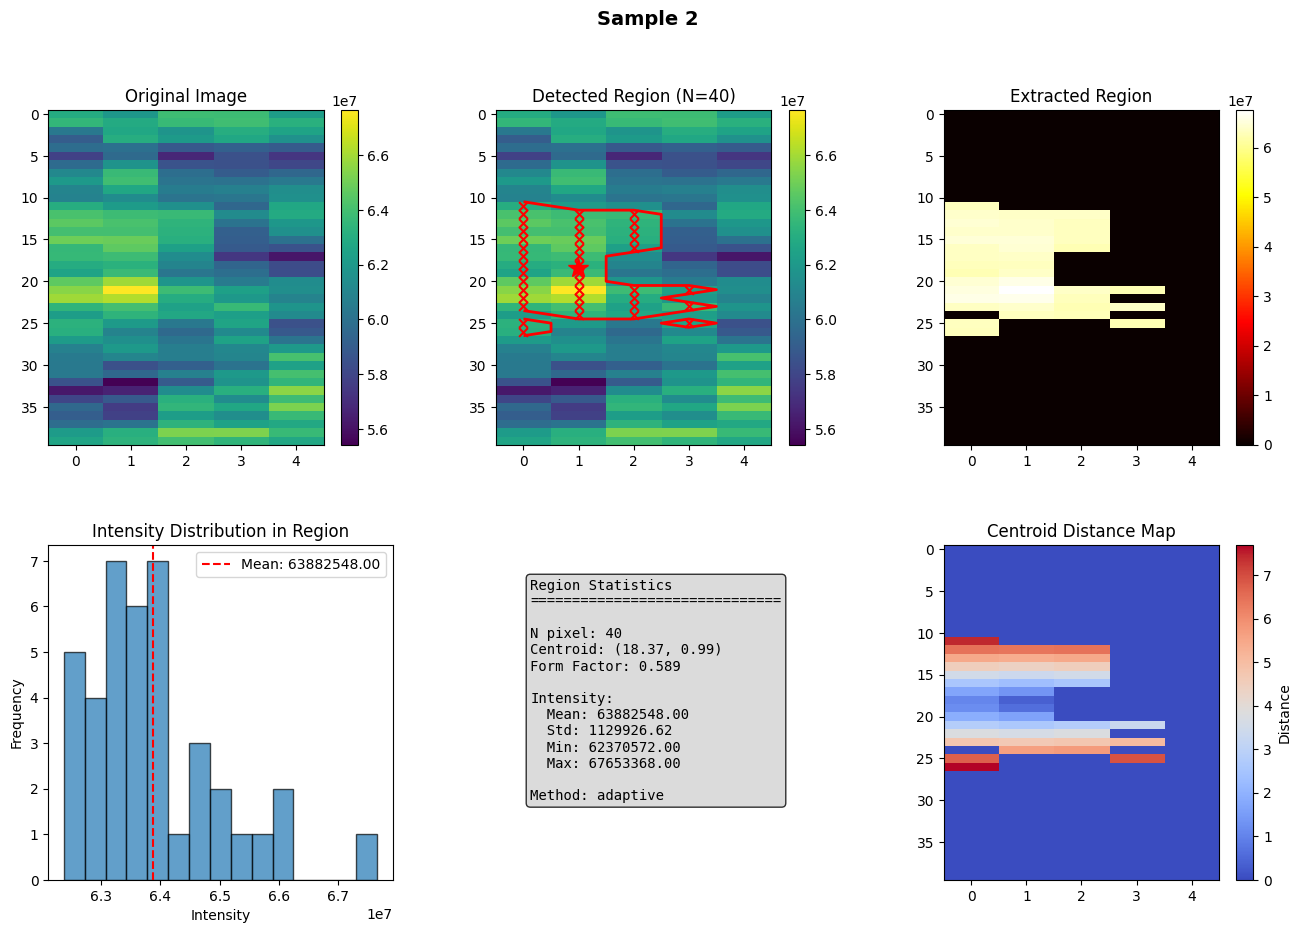

num_features: 2, num_holes: 2

Extracted Features (Sample 2)


Geometric:
  peak_perimeter                :  50.0000
  peak_centroid_x               :   0.9945
  peak_centroid_y               :  18.3728
  peak_bbox_width               :   4.0000
  peak_bbox_height              :  16.0000
  peak_aspect_ratio             :   0.2500

Form:
  peak_compactness              :   0.5948
  peak_circularity              :   0.5948
  peak_solidity                 :   0.7273
  peak_eccentricity             :   0.9762
  peak_elongation               :   4.6086

Intensity:
  peak_intensity_mean           : 63882548.0000
  peak_intensity_std            : 1129926.6250
  peak_intensity_max            : 67653368.0000

Spatial:
  peak_distance_to_center       :   2.2168
  peak_spatial_spread_total     :   4.4141

Texture:
  peak_contrast                 :   1.7083
  peak_homogeneity              :   0.7573
  peak_energy                   :   0.5527


In [8]:
detector_adaptive = PeakRegionDetector(N=40, method='adaptive')
fig, features = analyze_single_example(fit_data, sample_idx=2, 
                                      detector=detector_adaptive, 
                                      show_features=True)

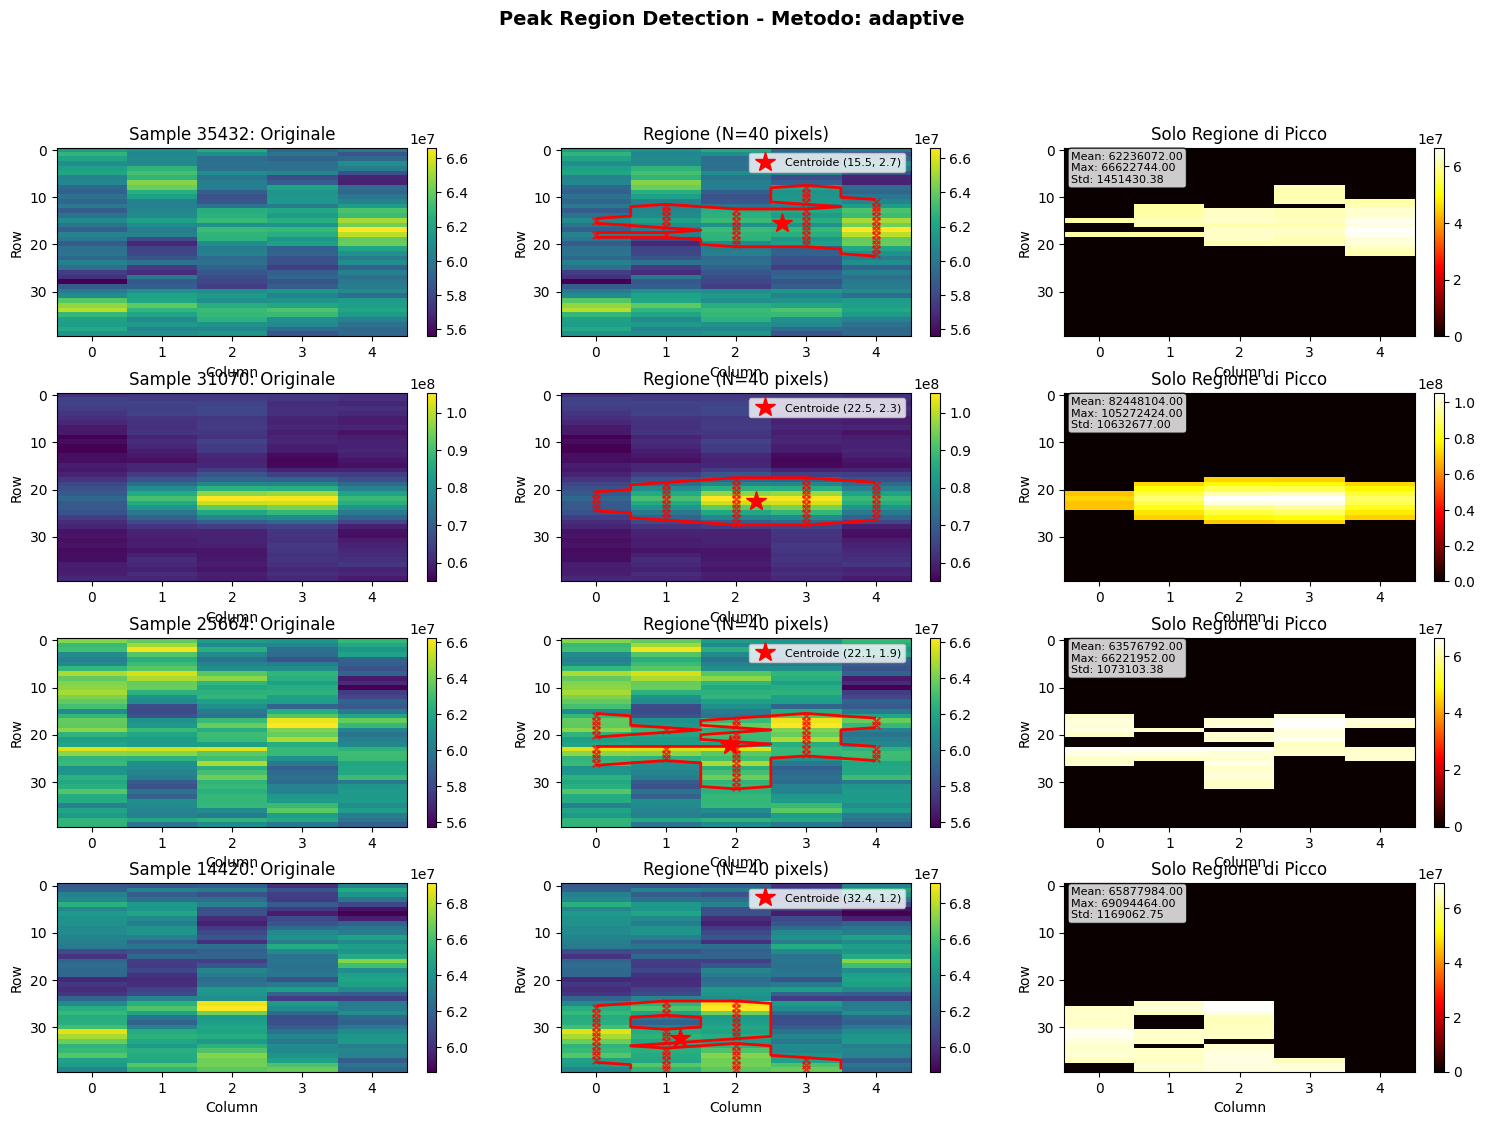

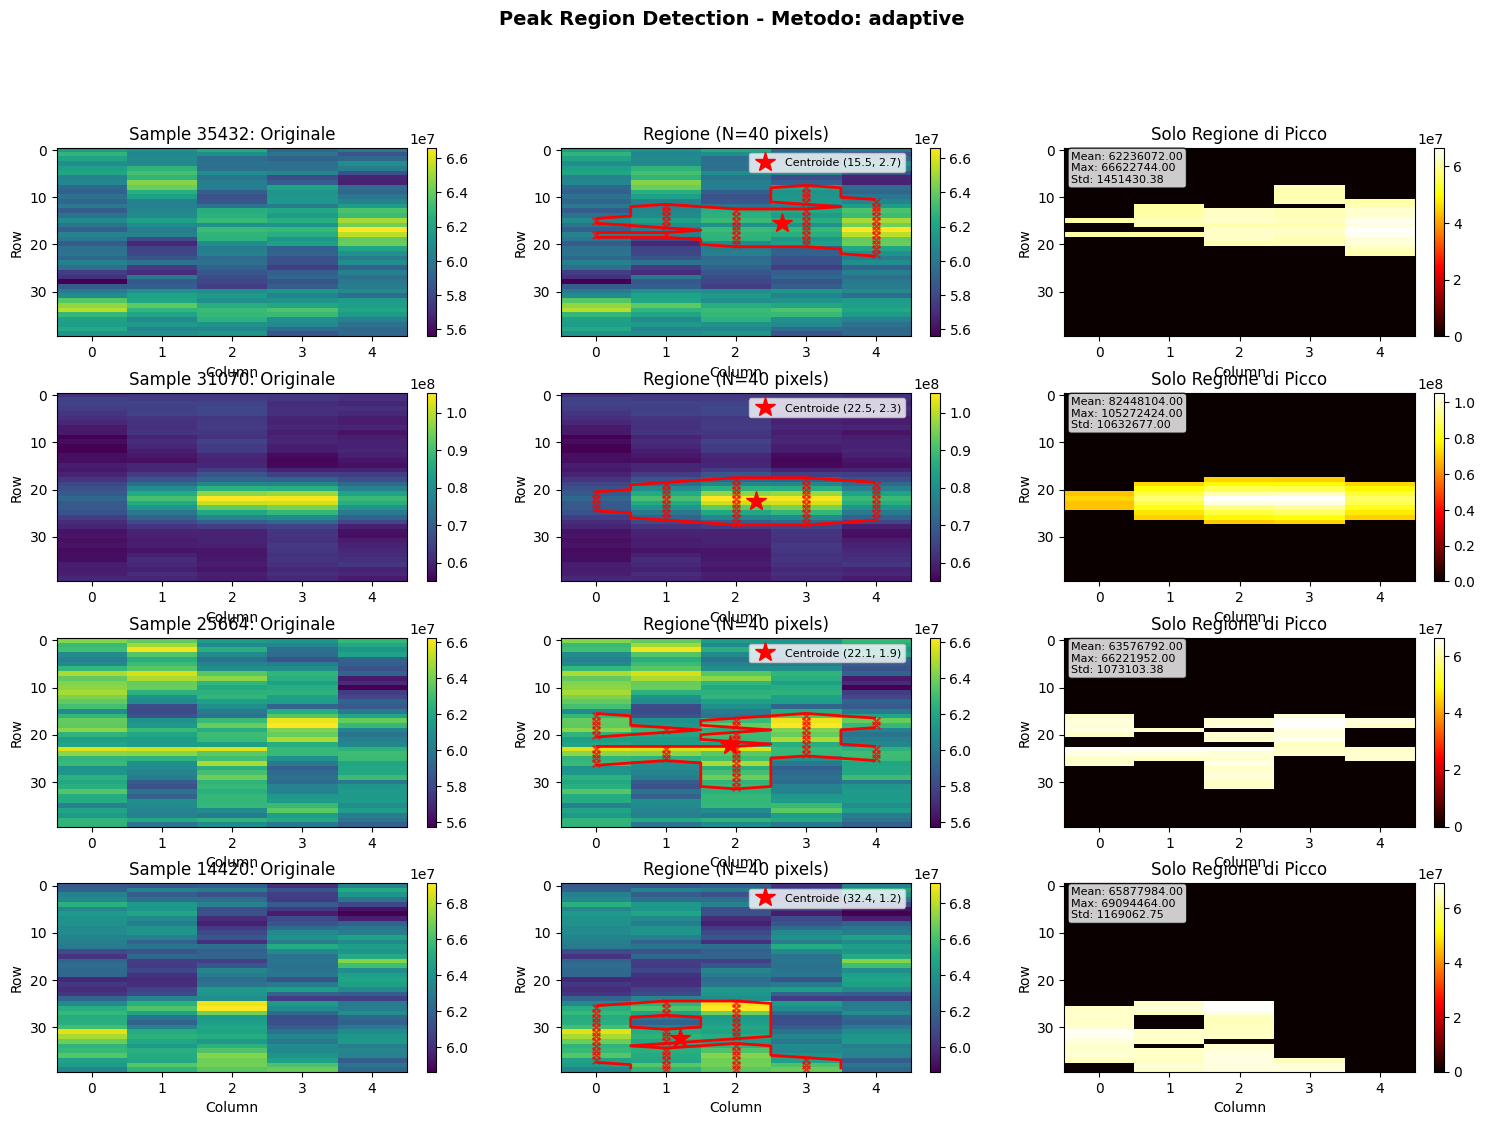

In [9]:
peak_extractor = PeakRegionDetector(N=40, method='adaptive')
visualize_multiple_examples(fit_data, peak_extractor, n_examples=4, random_seed=42)